# Klasifikasi Penggunaan dan Tutupan Lahan (Land Use / Land Cover) Jawa Timur
## Citra Sentinel-2A + Algoritma Decision Tree & Machine Learning + Visualisasi Folium (Google Satellite)

**Mata kuliah:** Penambangan Sains Data (PSD) — Analisis Spasial Penggunaan Lahan dan Kebijakan Publik  
**Wilayah Studi:** Provinsi Jawa Timur (111°–114,6° BT dan 6,5°–8,8° LS)  
**Target Klasifikasi:** 6 Kelas — Sawah, Bangunan, Mangrove, Lahan Hijau, Perairan Terbuka (Laut), Danau

Notebook ini berisi alur lengkap: **Data Understanding → Data Collection → Deskripsi Fitur & Rumus → Eksplorasi Data (EDA) → Pemodelan Machine Learning (Decision Tree) → Eksperimen Komprehensif → Peta Hasil Klasifikasi (Folium + Google Satellite) → Kesimpulan & Rekomendasi Kebijakan**.

---
### Daftar Isi
1. **Data Understanding** (Latar Belakang, Tujuan Analisis LULC, Wilayah Studi, Kelas & Jumlah Data, Band Sentinel-2A, Alur Kerja)
2. **Data Collection** (Persiapan Lingkungan, Membaca Shapefile, Penentuan Titik Sampel, Ekstraksi Nilai Citra Sentinel-2A)
3. **Deskripsi Fitur dan Rumusnya** (10 Band Asli & 8 Indeks Spektral beserta Rumus Matematis)
4. **Eksplorasi Data (EDA)** (Distribusi Sampel, Statistik Deskriptif, Tanda Tangan Spektral, Boxplot Indeks, Matriks Korelasi)
5. **Pemodelan Machine Learning** (Decision Tree Classifier, Pembagian Data Train/Test, Evaluasi Akurasi, Kappa, Confusion Matrix)
6. **Eksperimen** (Rasio Split Train:Test, Kombinasi Fitur A–E, Hyperparameter Tuning Grid Search, Model Final)
7. **Peta Hasil Klasifikasi** (Folium + Google Maps Satellite Hybrid + Floating Legend)
8. **Kesimpulan & Rekomendasi Kebijakan**

---
# 1. Data Understanding

## 1.1 Latar Belakang
Informasi penggunaan dan tutupan lahan (*Land Use / Land Cover*, LULC) penting untuk perencanaan tata ruang, pemantauan alih fungsi lahan pertanian pangan, pelestarian ekosistem pesisir, dan pengelolaan sumber daya air. Pemetaan terestrial manual memerlukan waktu dan biaya besar. Citra satelit multispektral seperti **Sentinel-2A** menyediakan data terbuka, beresolusi tinggi (10 m), dan memiliki periode ulang orbit beberapa hari, sehingga sangat ideal untuk klasifikasi lahan secara otomatis dengan teknik *machine learning*.

## 1.2 Tujuan Analisis *Land Use and Land Classification*
1. **Mengklasifikasikan** tutupan/penggunaan lahan di wilayah Jawa Timur ke dalam 6 kelas (Sawah, Bangunan, Mangrove, Lahan Hijau, Perairan Terbuka/Laut, Danau) berdasarkan nilai reflektansi band Sentinel-2A dan indeks spektralnya.
2. **Memahami karakteristik spektral** tiap kelas lahan, yaitu band dan indeks mana yang paling efektif membedakan satu kelas dari kelas lain.
3. **Membangun dan mengevaluasi model Decision Tree** (akurasi, presisi, *recall*, F1-score, Cohen's Kappa, *confusion matrix*) pada data *training* dan *testing*.
4. **Melakukan eksperimen** terhadap rasio pembagian data, kombinasi fitur, serta hyperparameter pohon keputusan (*depth*, kriteria *split*, kemurnian daun) untuk memperoleh konfigurasi optimal.
5. **Menyajikan peta hasil klasifikasi** di atas citra satelit Google Maps resolusi tinggi menggunakan Folium agar mudah diinterpretasikan secara spasial bagi pengambil kebijakan.

## 1.3 Wilayah Studi
Provinsi **Jawa Timur**, Indonesia (kira-kira 111°–114,6° BT dan 6,5°–8,8° LS). Wilayah ini mencakup kawasan heterogen: kompleks pegunungan dan taman nasional (Bromo-Tengger-Semeru, Alas Purwo, Tahura Raden Soerjo), dataran persawahan irigasi teknis (Pasuruan, Mojokerto, Lamongan), kawasan perkotaan padat (Surabaya Raya), pesisir mangrove (Wonorejo, Ujung Pangkah), perairan daratan (Ranu Klakah, Ranu Kumbolo, waduk Karangkates), serta perairan laut (Selat Madura, Laut Jawa, Samudra Hindia).

## 1.4 Kelas dan Jumlah Data
Data referensi berupa **Shapefile poligon** yang memuat area contoh (*training area*) tiap kelas tutupan lahan:

| ID | Kelas | Berkas Shapefile | Target Jumlah Sampel |
| :---: | :--- | :--- | :---: |
| 1 | Sawah | `sawahfix/input.shp` | 50 |
| 2 | Bangunan | `Bangunanfix/input.shp` | 50 |
| 3 | Mangrove | `mangrovefix/input.shp` | 50 |
| 4 | Lahan Hijau | `Lahanhijaufix/input.shp` | 50 |
| 5 | Perairan Terbuka (Laut) | `lautfix/input.shp` | **35** |
| 6 | Danau | `danau_fix/input.shp` | 50 |
| **Total** | **6 Kelas** | | **285 sampel** |

> **Catatan Keseimbangan Sampel:**  
> Target sampel Danau ditetapkan sebanyak 50 sampel dan Perairan Terbuka (Laut) sebanyak 35 sampel (mencakup Laut Jawa utara, Samudera Hindia selatan, dan Selat Madura) untuk menyeimbangkan representasi kelas perairan dengan kelas daratan ($50:50:50:50:35:50$). Penambahan dan persebaran sampel laut ini krusial agar model klasifikasi tidak keliru mengelompokkan wilayah perairan laut lepas/pesisir sebagai danau (*speckle noise*). Pembagian data dilakukan dengan *stratified split* agar proporsi kelas pada data training dan testing tetap konsisten.

## 1.5 Band pada Sentinel-2A
Sensor **MultiSpectral Instrument (MSI)** pada Sentinel-2A membawa **13 band** pada rentang cahaya tampak sampai inframerah gelombang pendek (SWIR) dengan lebar sapuan 290 km:

| Band | Nama Band | Panjang Gelombang Tengah (nm) | Resolusi Spasial | Kegunaan Utama | Status Penggunaan |
| :---: | :--- | :---: | :---: | :--- | :---: |
| **B1** | Coastal Aerosol | 443 nm | 60 m | Koreksi aerosol atmosfer, studi perairan pesisir | Tidak |
| **B2** | Blue (Biru) | 492 nm | 10 m | Penetrasi air, pembeda tanah/vegetasi, bangunan | **Ya** |
| **B3** | Green (Hijau) | 560 nm | 10 m | Puncak pantulan vegetasi sehat, indeks air | **Ya** |
| **B4** | Red (Merah) | 665 nm | 10 m | Penyerapan klorofil, pembeda vegetasi dan tanah | **Ya** |
| **B5** | Red Edge 1 | 704 nm | 20 m | Kandungan klorofil, kesehatan vegetasi | **Ya** |
| **B6** | Red Edge 2 | 740 nm | 20 m | Struktur kanopi vegetasi | **Ya** |
| **B7** | Red Edge 3 | 783 nm | 20 m | Kerapatan tajuk kanopi vegetasi | **Ya** |
| **B8** | NIR (Near Infrared) | 833 nm | 10 m | Biomassa vegetasi, pemisah daratan dan air | **Ya** |
| **B8A**| Narrow NIR | 865 nm | 20 m | Vegetasi, kadar air tanaman (spektral sempit) | **Ya** |
| **B9** | Water Vapour | 945 nm | 60 m | Koreksi uap air atmosfer | Tidak |
| **B10**| SWIR - Cirrus | 1374 nm | 60 m | Deteksi awan cirrus (Level-1C) | Tidak |
| **B11**| SWIR 1 | 1614 nm | 20 m | Kelembapan tanah/daun, area terbangun, pembeda air | **Ya** |
| **B12**| SWIR 2 | 2202 nm | 20 m | Tanah terbuka, area terbangun, geologi batuan | **Ya** |

Produk yang digunakan adalah **Sentinel-2 Level-2A (Surface Reflectance)** dari **Copernicus Data Space Ecosystem (CDSE)** yang telah terkoreksi secara atmosferik (Bottom-of-Atmosphere).

## 1.6 Alur Kerja (Workflow)
```
Shapefile (6 kelas) -> Titik Sampel (285 Titik) -> Ekstraksi Nilai Band Sentinel-2A
    -> Perhitungan 8 Indeks Spektral -> Dataset Fitur Lengkap (18 Fitur) -> EDA
    -> Stratified Split (Train:Test 80:20) -> Decision Tree Classifier -> Evaluasi Performa
    -> Eksperimen (Rasio Split, Kombinasi Fitur, Hyperparameter Tuning) -> Model Final
    -> Visualisasi Peta Folium Interaktif (Google Maps Satellite Hybrid)
```

---
# 2. Data Collection

## 2.1 Persiapan Lingkungan dan Konfigurasi
Modul Python yang digunakan mencakup `geopandas`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `folium`, dan `scikit-learn`.

In [49]:
import os, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from shapely.geometry import Point

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             cohen_kappa_score, f1_score)

# ----------------- KONFIGURASI PROYEK -----------------
DATA_DIR    = "."
SEED        = 42
CSV_DATASET = "dataset_sentinel2_jatim.csv"

KELAS = {
    1: dict(nama="Sawah",                   file="sawahfix",       n=50, warna="#FFD92F"),
    2: dict(nama="Bangunan",                file="Bangunanfix",    n=50, warna="#E41A1C"),
    3: dict(nama="Mangrove",                file="mangrovefix",    n=50, warna="#8E44AD"),
    4: dict(nama="Lahan Hijau",             file="Lahanhijaufix",  n=50, warna="#2E7D32"),
    5: dict(nama="Perairan Terbuka (Laut)", file="lautfix",        n=35, warna="#0D47A1"),
    6: dict(nama="Danau",                   file="danau_fix",      n=50, warna="#4FC3F7"),
}

NAMA_KELAS  = [v["nama"] for v in KELAS.values()]
WARNA_KELAS = {v["nama"]: v["warna"] for v in KELAS.values()}

print(f"Jumlah kelas: {len(KELAS)} -> {NAMA_KELAS}")


Jumlah kelas: 6 -> ['Sawah', 'Bangunan', 'Mangrove', 'Lahan Hijau', 'Perairan Terbuka (Laut)', 'Danau']


## 2.2 Membaca Shapefile dan Menentukan Titik Sampel
Setiap Shapefile berisi poligon area contoh. Titik sampel diambil dari poligon menggunakan `representative_point()`, yang menjamin bahwa titik sampel selalu berada di dalam poligon.

In [50]:
# Fungsi membaca dan memvalidasi shapefile
def baca_shp(path):
    g = gpd.read_file(path)
    g = g.set_crs(4326) if g.crs is None else g.to_crs(4326)
    g = g[g.geometry.notnull() & ~g.geometry.is_empty].copy()
    g["geometry"] = g.geometry.apply(lambda x: x if x.is_valid else x.buffer(0))
    return g[["geometry"]].reset_index(drop=True)

def cari_shp(nama):
    target = nama.lower()
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if f.lower().endswith(".shp") and (target in root.lower() or target in f.lower()):
                return os.path.join(root, f)
    raise FileNotFoundError(f"File {nama}.shp tidak ditemukan di {DATA_DIR}")

jalur_shp = {k: cari_shp(v["file"]) for k, v in KELAS.items()}
for k, p in jalur_shp.items():
    print(f"{KELAS[k]['nama']:<26} -> {p}")

poligon = {k: baca_shp(p) for k, p in jalur_shp.items()}

ringkas = []
for k, v in KELAS.items():
    g = poligon[k]
    b = g.total_bounds
    ringkas.append({
        "ID": k, "Kelas": v["nama"], "Jumlah poligon": len(g),
        "Target sampel": v["n"],
        "BT min": round(b[0], 3), "LS min": round(b[1], 3),
        "BT maks": round(b[2], 3), "LS maks": round(b[3], 3)
    })
pd.DataFrame(ringkas).set_index("ID")


Sawah                      -> .\sawahfix\input.shp
Bangunan                   -> .\Bangunanfix\input.shp
Mangrove                   -> .\mangrovefix\input.shp
Lahan Hijau                -> .\Lahanhijaufix\input.shp
Perairan Terbuka (Laut)    -> .\lautfix\input.shp
Danau                      -> .\danau_fix\input.shp


,Kelas,Jumlah poligon,Target sampel,BT min,LS min,BT maks,LS maks
ID,,,,,,,
1,Sawah,52,50,110.918,-8.465,114.246,-7.015
2,Bangunan,50,50,111.526,-8.197,113.656,-7.114
3,Mangrove,53,50,112.669,-8.601,115.355,-6.827
4,Lahan Hijau,50,50,110.993,-8.606,114.060,-7.688
5,Perairan Terbuka (Laut),50,35,111.148,-9.249,114.554,-6.453
6,Danau,50,50,110.895,-8.615,114.608,-7.047


---
# 3. Deskripsi Fitur dan Rumusnya

Model klasifikasi menggunakan **18 fitur**, yang terdiri dari **10 band asli reflektansi Sentinel-2A** dan **8 indeks spektral turunan**.

## 3.1 Fitur Band Asli (10 Fitur)
| Fitur | Deskripsi Saluran | Panjang Gelombang | Satuan |
| :---: | :--- | :---: | :---: |
| `B2` | Reflektansi Biru (Blue) | 492 nm | 0–1 |
| `B3` | Reflektansi Hijau (Green) | 560 nm | 0–1 |
| `B4` | Reflektansi Merah (Red) | 665 nm | 0–1 |
| `B5` | Reflektansi *Red Edge* 1 | 704 nm | 0–1 |
| `B6` | Reflektansi *Red Edge* 2 | 740 nm | 0–1 |
| `B7` | Reflektansi *Red Edge* 3 | 783 nm | 0–1 |
| `B8` | Reflektansi Inframerah Dekat (NIR) | 833 nm | 0–1 |
| `B8A`| Reflektansi *Narrow* NIR | 865 nm | 0–1 |
| `B11`| Reflektansi Inframerah Gelombang Pendek 1 (SWIR 1) | 1614 nm | 0–1 |
| `B12`| Reflektansi Inframerah Gelombang Pendek 2 (SWIR 2) | 2202 nm | 0–1 |

## 3.2 Fitur Indeks Spektral (8 Fitur)
| Fitur | Nama Lengkap Indeks | Rumus Matematis | Rentang Nilai | Interpretasi Biofisik |
| :---: | :--- | :---: | :---: | :--- |
| **NDVI** | Normalized Difference Vegetation Index | $\frac{B8 - B4}{B8 + B4}$ | $-1$ s.d. $+1$ | Nilai tinggi = vegetasi rapat; rendah/negatif = air, bangunan, tanah terbuka |
| **NDWI** | Normalized Difference Water Index (McFeeters) | $\frac{B3 - B8}{B3 + B8}$ | $-1$ s.d. $+1$ | Positif = badan air terbuka; negatif = vegetasi dan lahan darat |
| **MNDWI**| Modified NDWI (Xu) | $\frac{B3 - B11}{B3 + B11}$ | $-1$ s.d. $+1$ | Mereduksi pantulan semu area terbangun pada pemetaan air |
| **NDBI** | Normalized Difference Built-up Index | $\frac{B11 - B8}{B11 + B8}$ | $-1$ s.d. $+1$ | Nilai positif tinggi = area terbangun, pemukiman, dan infrastruktur beton |
| **NDRE** | Normalized Difference Red Edge | $\frac{B8 - B5}{B8 + B5}$ | $-1$ s.d. $+1$ | Sangat sensitif terhadap kandungan klorofil daun kanopi lebat |
| **EVI**  | Enhanced Vegetation Index | $2.5 \times \frac{B8 - B4}{B8 + 6B4 - 7.5B2 + 1}$ | $\approx -1$ s.d. $+1$ | Indeks vegetasi terkoreksi atmosfer, tidak mudah jenuh pada kanopi rapat |
| **SAVI** | Soil Adjusted Vegetation Index | $1.5 \times \frac{B8 - B4}{B8 + B4 + 0.5}$ | $\approx -1.5$ s.d. $+1.5$ | Mengoreksi pengaruh kecerahan tanah pada vegetasi jarang/sawah bera |
| **BSI**  | Bare Soil Index | $\frac{(B11 + B4) - (B8 + B2)}{(B11 + B4) + (B8 + B2)}$ | $-1$ s.d. $+1$ | Nilai tinggi = tanah terbuka, sawah siap tanam, tapak konstruksi |

In [51]:
# Definisi nama kolom fitur
BAND_ASLI   = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
INDEKS      = ["NDVI", "NDWI", "MNDWI", "NDBI", "NDRE", "EVI", "SAVI", "BSI"]
FITUR_SEMUA = BAND_ASLI + INDEKS

# Load Dataset CSV
df = pd.read_csv(CSV_DATASET)

# ===== HITUNG INDEKS SPEKTRAL DARI BAND MENTAH =====
# Fungsi bantu: safe normalized difference (hindari pembagian nol)
def _nd(a, b):
    return (a - b) / (a + b + 1e-10)

# 1. NDVI  = (B8 - B4) / (B8 + B4)
df["NDVI"] = _nd(df["B8"], df["B4"])

# 2. NDWI  = (B3 - B8) / (B3 + B8)
df["NDWI"] = _nd(df["B3"], df["B8"])

# 3. MNDWI = (B3 - B11) / (B3 + B11)
df["MNDWI"] = _nd(df["B3"], df["B11"])

# 4. NDBI  = (B11 - B8) / (B11 + B8)
df["NDBI"] = _nd(df["B11"], df["B8"])

# 5. NDRE  = (B8 - B5) / (B8 + B5)   (Normalized Difference Red Edge)
df["NDRE"] = _nd(df["B8"], df["B5"])

# 6. EVI   = 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1)
df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1 + 1e-10)

# 7. SAVI  = (B8 - B4) * (1 + L) / (B8 + B4 + L),  L = 0.5
L = 0.5
df["SAVI"] = (df["B8"] - df["B4"]) * (1 + L) / (df["B8"] + df["B4"] + L + 1e-10)

# 8. BSI   = ((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))
df["BSI"] = _nd(df["B11"] + df["B4"], df["B8"] + df["B2"])

print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"  - Band asli   : {BAND_ASLI}")
print(f"  - Indeks hitung: {INDEKS}")
print(f"  - Total fitur  : {len(FITUR_SEMUA)}")
print(f"Daftar 18 Fitur Analisis: {FITUR_SEMUA}\n")
df.head()


Dataset berhasil dimuat: 285 baris, 26 kolom
  - Band asli   : ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
  - Indeks hitung: ['NDVI', 'NDWI', 'MNDWI', 'NDBI', 'NDRE', 'EVI', 'SAVI', 'BSI']
  - Total fitur  : 18
Daftar 18 Fitur Analisis: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDBI', 'NDRE', 'EVI', 'SAVI', 'BSI']



,id,kelas,wilayah,lat,lon,Latitude,Longitude,poligon_id,B2,B3,...,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
0,0,Sawah,sawahfix,-7.700192,111.955981,-7.700192,111.955981,0,0.0550,0.1170,...,0.1356,0.0925,0.701375,-0.588608,-0.073634,-0.538304,0.447613,0.614646,0.541897,-0.404462
1,1,Sawah,sawahfix,-7.701140,111.956453,-7.701140,111.956453,1,0.0423,0.1120,...,0.1221,0.1576,0.728141,-0.615385,-0.043144,-0.587848,0.462005,0.620480,0.569322,-0.446670
2,2,Sawah,sawahfix,-7.387015,112.707783,-7.387015,112.707783,2,0.0733,0.0727,...,0.1504,0.1220,0.738655,-0.679665,-0.348274,-0.434161,0.467565,0.689002,0.517688,-0.372697
3,3,Sawah,sawahfix,-7.384762,112.714195,-7.384762,112.714195,3,0.0573,0.0775,...,0.1492,0.1093,0.667559,-0.656472,-0.316277,-0.429336,0.429063,0.537762,0.473318,-0.316634
4,4,Sawah,sawahfix,-8.457965,114.104932,-8.457965,114.104932,4,0.0582,0.1071,...,0.1792,0.0837,0.765846,-0.606612,-0.251834,-0.418748,0.481958,0.703166,0.571730,-0.352620


---
# 4. Eksplorasi Data (EDA)

## 4.1 Jumlah Data per Kelas
Memeriksa komposisi dataset 285 sampel (50 untuk kelas daratan & danau, 35 untuk laut):

Jumlah kelas : 6
Jumlah data  : 285


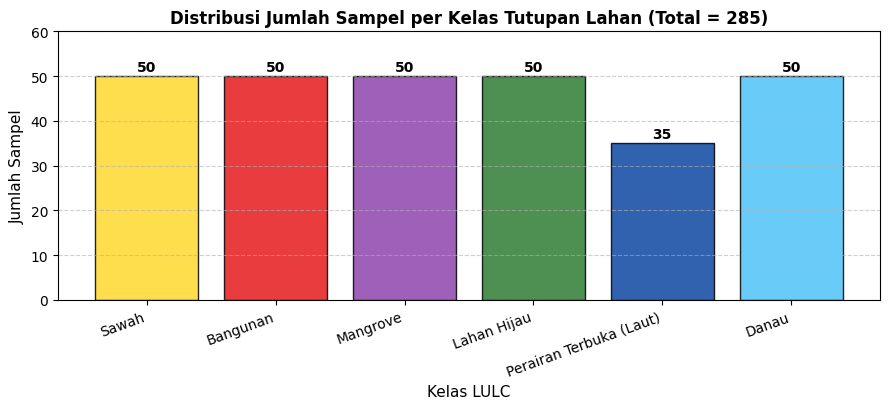

,Jumlah Sampel
kelas,
Sawah,50
Bangunan,50
Mangrove,50
Lahan Hijau,50
Perairan Terbuka (Laut),35
Danau,50


In [52]:
jml = df["kelas"].value_counts().reindex(NAMA_KELAS)
print("Jumlah kelas :", df["kelas"].nunique())
print("Jumlah data  :", len(df))

plt.figure(figsize=(9, 4.2))
colors = [WARNA_KELAS[k] for k in NAMA_KELAS]
plt.bar(jml.index, jml.values, color=colors, edgecolor='black', alpha=0.85)
plt.title("Distribusi Jumlah Sampel per Kelas Tutupan Lahan (Total = 285)", fontsize=12, fontweight='bold')
plt.xlabel("Kelas LULC", fontsize=11)
plt.ylabel("Jumlah Sampel", fontsize=11)
plt.ylim(0, 60)
for i, v in enumerate(jml.values):
    plt.text(i, v + 1.2, f"{v}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

jml.to_frame("Jumlah Sampel")


## 4.2 Statistik Deskriptif Fitur
Menghitung rata-rata dan simpangan baku seluruh fitur serta rata-rata fitur per kelas:

In [53]:
print("Rata-rata Fitur per Kelas LULC:")
df_mean_kelas = df.groupby("kelas")[FITUR_SEMUA].mean().reindex(NAMA_KELAS).round(3)
df_mean_kelas


Rata-rata Fitur per Kelas LULC:


,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
kelas,,,,,,,,,,,,,,,,,,
Sawah,0.059,0.092,0.071,0.161,0.286,0.376,0.430,0.421,0.169,0.117,0.714,-0.646,-0.291,-0.436,0.454,0.639,0.535,-0.341
Bangunan,0.173,0.206,0.227,0.234,0.244,0.252,0.256,0.251,0.354,0.293,0.062,-0.107,-0.264,0.161,0.043,0.070,0.045,0.150
Mangrove,0.029,0.049,0.027,0.187,0.410,0.569,0.665,0.652,0.077,0.052,0.921,-0.863,-0.207,-0.793,0.561,0.987,0.800,-0.739
Lahan Hijau,0.038,0.059,0.035,0.174,0.368,0.507,0.590,0.578,0.139,0.086,0.888,-0.818,-0.399,-0.620,0.545,0.918,0.739,-0.567
Perairan Terbuka (Laut),0.103,0.054,0.026,0.023,0.019,0.016,0.014,0.014,0.010,0.008,-0.279,0.576,0.678,-0.220,-0.238,-0.100,-0.033,-0.520
Danau,0.058,0.081,0.032,0.032,0.032,0.032,0.032,0.032,0.016,0.014,-0.017,0.434,0.671,-0.336,-0.022,0.001,-0.000,-0.304


## 4.3 Tanda Tangan Spektral (*Spectral Signature*)
Kurva reflektansi spektral memperlihatkan karakteristik fisis tiap kelas tutupan lahan pada spektrum tampak hingga inframerah gelombang pendek (492 nm – 2202 nm):

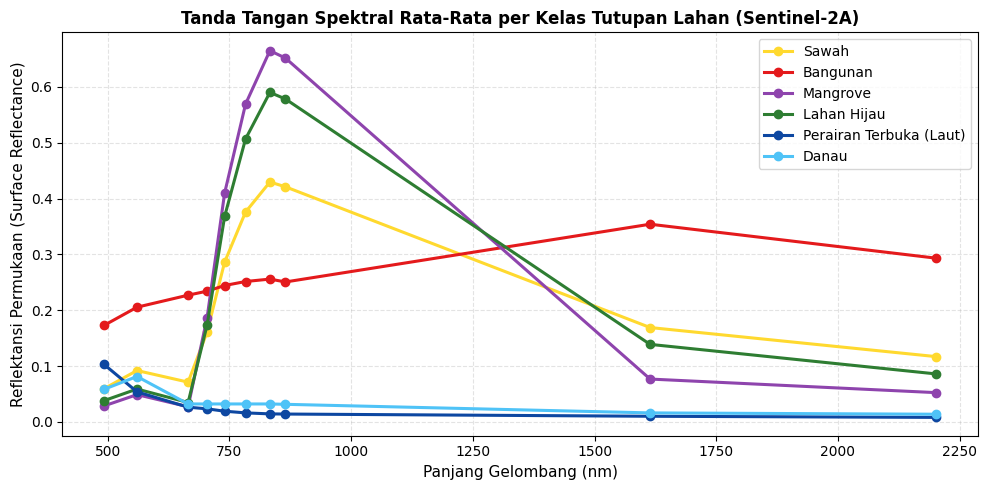

In [54]:
panjang_gelombang = [492, 560, 665, 704, 740, 783, 833, 865, 1614, 2202]
rata = df.groupby("kelas")[BAND_ASLI].mean().reindex(NAMA_KELAS)

plt.figure(figsize=(10, 5))
for k in NAMA_KELAS:
    plt.plot(panjang_gelombang, rata.loc[k].values, marker="o", lw=2.2, label=k, color=WARNA_KELAS[k])
plt.xlabel("Panjang Gelombang (nm)", fontsize=11)
plt.ylabel("Reflektansi Permukaan (Surface Reflectance)", fontsize=11)
plt.title("Tanda Tangan Spektral Rata-Rata per Kelas Tutupan Lahan (Sentinel-2A)", fontsize=12, fontweight='bold')
plt.grid(alpha=0.35, linestyle='--')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 4.4 Sebaran Indeks Spektral per Kelas
*Boxplot* menunjukkan rentang nilai indeks dan kemampuan pemisahan (*separability*) antar-kelas tutupan lahan:

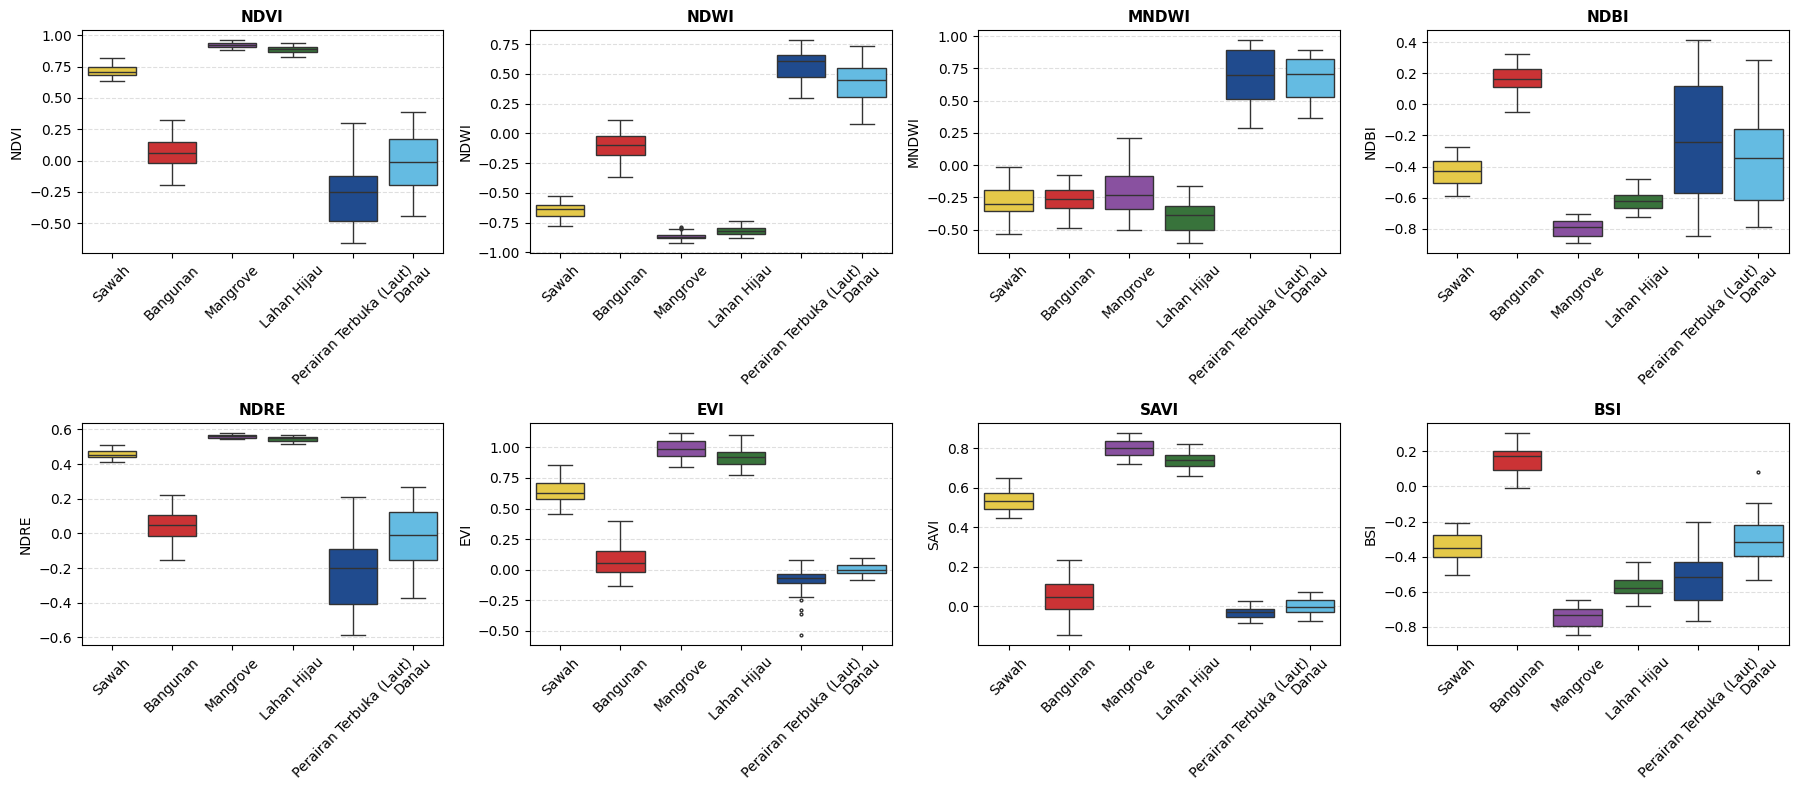

In [55]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.ravel(), INDEKS):
    sns.boxplot(data=df, x="kelas", y=f, order=NAMA_KELAS, palette=WARNA_KELAS, ax=ax, fliersize=2)
    ax.set_title(f, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 4.5 Korelasi Antar Fitur
Matriks korelasi Pearson menunjukkan hubungan linier antar 18 fitur spektral:

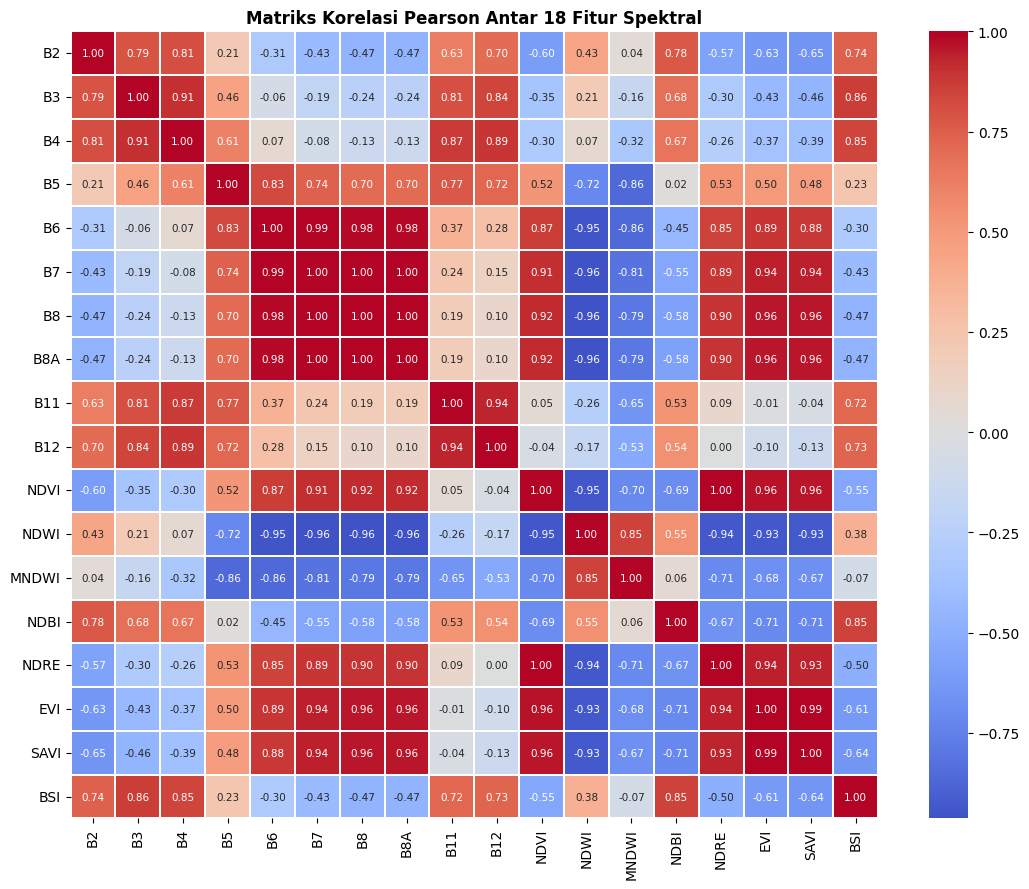

In [56]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[FITUR_SEMUA].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7.5}, linewidths=0.3)
plt.title("Matriks Korelasi Pearson Antar 18 Fitur Spektral", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 5. Pemodelan Machine Learning: Decision Trees

## 5.1 Algoritma Decision Tree (CART)
Algoritma **Decision Tree** (*Classification and Regression Trees*) membagi ruang fitur secara hierarkis (*recursive partitioning*) menggunakan kriteria **Gini Impurity**:
$$I_G(p) = 1 - \sum_{i=1}^{C} p_i^2$$

**Keunggulan Utama Decision Tree untuk Analisis SIG & Kebijakan:**
1. **Model White-Box yang Sangat Transparan:** Menghasilkan aturan keputusan (*if-then rules*) eksplisit yang dapat divalidasi langsung oleh analis tata ruang dan pejabat pembuat komitmen.
2. **Invariant terhadap Skala Fitur:** Tidak terpengaruh perbedaan skala antara reflektansi band (0.01–0.4) dan indeks ($-1$ s.d. $+1$).
3. **Ekspor Aturan ke GIS:** Aturan pohon keputusan dapat langsung diubah menjadi query kondisi spasial (*raster calculator*) di QGIS / ArcGIS.

## 5.2 Pembagian Data Training dan Testing
Dataset dibagi menggunakan **Stratified Train-Test Split (80:20)** agar proporsi setiap kelas dipertahankan secara proporsional:
* **Total Sampel:** 285 titik
* **Data Training (80%):** 228 sampel (40 Sawah, 40 Bangunan, 40 Mangrove, 40 Lahan Hijau, 28 Laut, 40 Danau)
* **Data Testing (20%):** 57 sampel (10 Sawah, 10 Bangunan, 10 Mangrove, 10 Lahan Hijau, 7 Laut, 10 Danau)

In [57]:
X = df[FITUR_SEMUA]
y = df["kelas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

tabel_split = pd.DataFrame({
    "Total":    y.value_counts(),
    "Training": y_train.value_counts(),
    "Testing":  y_test.value_counts(),
}).reindex(NAMA_KELAS)
tabel_split.loc["TOTAL"] = tabel_split.sum()

print(f"Jumlah kelas        : {y.nunique()}")
print(f"Jumlah data training: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Jumlah data testing : {len(X_test)} ({len(X_test)/len(X):.0%})\n")
tabel_split.astype(int)


Jumlah kelas        : 6
Jumlah data training: 228 (80%)
Jumlah data testing : 57 (20%)



,Total,Training,Testing
kelas,,,
Sawah,50,40,10
Bangunan,50,40,10
Mangrove,50,40,10
Lahan Hijau,50,40,10
Perairan Terbuka (Laut),35,28,7
Danau,50,40,10
TOTAL,285,228,57


## 5.3 Pelatihan dan Evaluasi Model Decision Tree
Metrik evaluasi yang digunakan meliputi:
* **Akurasi** (Overall Accuracy)
* **Presisi, Recall, F1-Score** per kelas
* **Cohen's Kappa** (kesepakatan klasifikasi di atas faktor kebetulan acak)
* **Confusion Matrix**

,Akurasi,Kappa,F1 macro
Dataset,,,
Training (228),0.9912,0.9894,0.9907
Testing (57),0.9474,0.9367,0.9464



--- Laporan Klasifikasi Data Testing (Decision Tree Baseline) ---
                         precision    recall  f1-score   support

                  Sawah     1.0000    1.0000    1.0000        10
               Bangunan     1.0000    1.0000    1.0000        10
               Mangrove     1.0000    0.8000    0.8889        10
            Lahan Hijau     0.8333    1.0000    0.9091        10
Perairan Terbuka (Laut)     0.8750    1.0000    0.9333         7
                  Danau     1.0000    0.9000    0.9474        10

               accuracy                         0.9474        57
              macro avg     0.9514    0.9500    0.9464        57
           weighted avg     0.9554    0.9474    0.9471        57



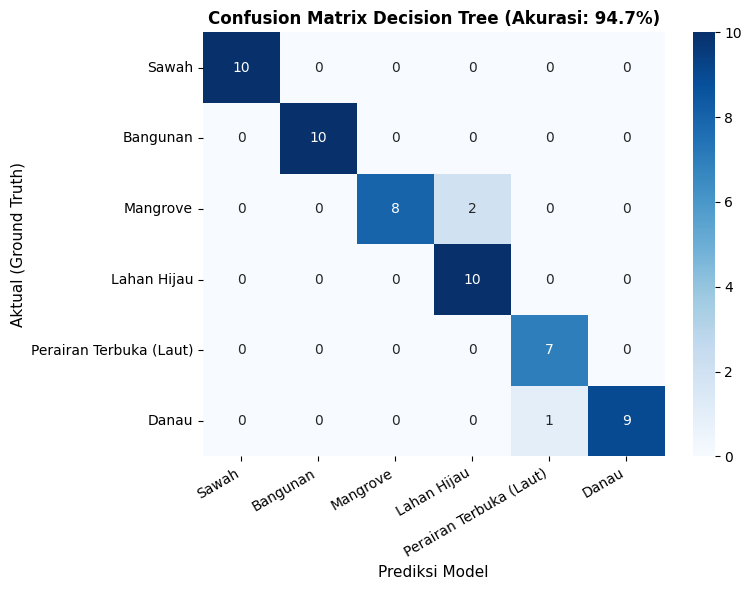

In [58]:
# Model Baseline Decision Tree
dt_baseline = DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=4, random_state=SEED)
dt_baseline.fit(X_train, y_train)

pred_train = dt_baseline.predict(X_train)
pred_test  = dt_baseline.predict(X_test)

def hitung_metrik(y_true, y_pred):
    return {
        "Akurasi": accuracy_score(y_true, y_pred),
        "Kappa":   cohen_kappa_score(y_true, y_pred),
        "F1 macro": f1_score(y_true, y_pred, average="macro"),
    }

ringkas_eval = pd.DataFrame([
    {"Dataset": "Training (228)", **hitung_metrik(y_train, pred_train)},
    {"Dataset": "Testing (57)",   **hitung_metrik(y_test,  pred_test)},
]).set_index("Dataset")
display(ringkas_eval.round(4))

print("\n--- Laporan Klasifikasi Data Testing (Decision Tree Baseline) ---")
print(classification_report(y_test, pred_test, labels=NAMA_KELAS, digits=4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, pred_test, labels=NAMA_KELAS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS)
plt.xlabel("Prediksi Model", fontsize=11)
plt.ylabel("Aktual (Ground Truth)", fontsize=11)
plt.title(f"Confusion Matrix Decision Tree (Akurasi: {accuracy_score(y_test, pred_test)*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


---
# 6. Eksperimen

Untuk menguji ketahanan model pada data berukuran 285 sampel, eksperimen dievaluasi menggunakan **Repeated Stratified 5-Fold Cross-Validation (10 pengulangan = 50 iterasi)**.

## 6.1 Eksperimen Rasio Training:Testing
Membandingkan dampak pembagian rasio data latih terhadap data uji (90:10, 80:20, 70:30, 60:40) dengan 10 variasi seed:

In [59]:
hasil_rasio = []
for ts in [0.10, 0.20, 0.30, 0.40]:
    skor = []
    for r in range(10):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=ts, stratify=y, random_state=SEED + r
        )
        m = DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=4, random_state=SEED)
        m.fit(X_tr, y_tr)
        skor.append(accuracy_score(y_te, m.predict(X_te)))
    hasil_rasio.append({
        "Rasio Train:Test": f"{int((1-ts)*100)}:{int(ts*100)}",
        "Ukuran Test": ts,
        "Akurasi Rata-rata": np.mean(skor),
        "Std Dev": np.std(skor),
    })

tab_rasio = pd.DataFrame(hasil_rasio)
tab_rasio.round(4)


,Rasio Train:Test,Ukuran Test,Akurasi Rata-rata,Std Dev
0,90:10,0.1,0.9828,0.0172
1,80:20,0.2,0.9561,0.0263
2,70:30,0.3,0.9500,0.0345
3,60:40,0.4,0.9456,0.0290


## 6.2 Eksperimen Kombinasi Fitur
Membandingkan 5 skenario kombinasi fitur untuk mengetahui apakah penambahan indeks spektral meningkatkan akurasi:
* **Skenario A:** 4 band dasar 10 m (`B2, B3, B4, B8`)
* **Skenario B:** 10 band Sentinel-2A
* **Skenario C:** 8 indeks spektral
* **Skenario D:** 4 indeks esensial (`NDVI, MNDWI, NDBI, BSI`)
* **Skenario E:** Semua fitur gabungan (18 fitur)

In [60]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

skenario_fitur = {
    "A. 4 band 10 m (B2,B3,B4,B8)":            ["B2", "B3", "B4", "B8"],
    "B. 10 band Sentinel-2A":                  BAND_ASLI,
    "C. 8 indeks spektral":                    INDEKS,
    "D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)": ["NDVI", "MNDWI", "NDBI", "BSI"],
    "E. Band + indeks (18 fitur)":             FITUR_SEMUA,
}

hasil_fitur = []
for nama_sken, cols in skenario_fitur.items():
    model = DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=4, random_state=SEED)
    s = cross_val_score(model, df[cols], y, cv=cv, scoring="accuracy")
    f = cross_val_score(model, df[cols], y, cv=cv, scoring="f1_macro")
    hasil_fitur.append({
        "Skenario Fitur": nama_sken,
        "Jumlah Fitur": len(cols),
        "Akurasi CV": s.mean(),
        "Std Dev": s.std(),
        "F1 Macro CV": f.mean()
    })

tab_fitur = pd.DataFrame(hasil_fitur).sort_values("Akurasi CV", ascending=False).reset_index(drop=True)
display(tab_fitur.round(4))

FITUR_FINAL_NAMA = tab_fitur.loc[0, "Skenario Fitur"]
FITUR_FINAL = skenario_fitur[FITUR_FINAL_NAMA]
print(f"\nSkenario Fitur Terbaik: {FITUR_FINAL_NAMA} ({len(FITUR_FINAL)} fitur)")


,Skenario Fitur,Jumlah Fitur,Akurasi CV,Std Dev,F1 Macro CV
0,E. Band + indeks (18 fitur),18,0.9600,0.0256,0.9567
1,B. 10 band Sentinel-2A,10,0.9477,0.0286,0.9449
2,"D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)",4,0.9182,0.0291,0.9056
3,C. 8 indeks spektral,8,0.9175,0.0318,0.9041
4,"A. 4 band 10 m (B2,B3,B4,B8)",4,0.8937,0.0391,0.8909



Skenario Fitur Terbaik: E. Band + indeks (18 fitur) (18 fitur)


## 6.3 Eksperimen Hyperparameter Decision Tree (Grid Search)
Mencari konfigurasi hyperparameter terbaik Decision Tree menggunakan Grid Search pada parameter `max_depth`, `criterion`, dan `min_samples_split`:

In [61]:
# Bagian 6: Grid Search
param_grid_dt = {
    "max_depth": [3, 4, 5, 6, 8],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2]
}

# Menambahkan class_weight='balanced' untuk menangani ketidakseimbangan kelas
grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    param_grid_dt,
    cv=5,
    scoring="accuracy"
)

# Perbaikan: Fit HANYA pada data training untuk menghindari data leakage
grid_dt.fit(X_train, y_train)

print("Hyperparameter Terbaik Decision Tree:")
print(grid_dt.best_params_)
print(f"Akurasi CV Terbaik: {grid_dt.best_score_*100:.2f}%")

# Simpan model terbaik untuk digunakan di pembuatan peta (Bagian 7)
model_final = grid_dt.best_estimator_

Hyperparameter Terbaik Decision Tree:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Akurasi CV Terbaik: 96.51%


## 6.4 Model Final Decision Tree & Aturan Keputusan (*Decision Rules*)
Melatih model final dengan parameter terbaik dan mengekstrak aturan logika percabangan pohon keputusan serta *Feature Importance*:

=== ATURAN POHON KEPUTUSAN FINAL (DECISION RULES) ===
|--- B4 <= 0.05
|   |--- B11 <= 0.04
|   |   |--- B2 <= 0.07
|   |   |   |--- B3 <= 0.06
|   |   |   |   |--- class: Perairan Terbuka (Laut)
|   |   |   |--- B3 >  0.06
|   |   |   |   |--- class: Danau
|   |   |--- B2 >  0.07
|   |   |   |--- B7 <= 0.02
|   |   |   |   |--- class: Perairan Terbuka (Laut)
|   |   |   |--- B7 >  0.02
|   |   |   |   |--- class: Danau
|   |--- B11 >  0.04
|   |   |--- NDBI <= -0.71
|   |   |   |--- B12 <= 0.09
|   |   |   |   |--- class: Mangrove
|   |   |   |--- B12 >  0.09
|   |   |   |   |--- class: Lahan Hijau
|   |   |--- NDBI >  -0.71
|   |   |   |--- B4 <= 0.02
|   |   |   |   |--- class: Lahan Hijau
|   |   |   |--- B4 >  0.02
|   |   |   |   |--- class: Lahan Hijau
|--- B4 >  0.05
|   |--- EVI <= 0.45
|   |   |--- class: Bangunan
|   |--- EVI >  0.45
|   |   |--- B3 <= 0.06
|   |   |   |--- class: Sawah
|   |   |--- B3 >  0.06
|   |   |   |--- class: Sawah



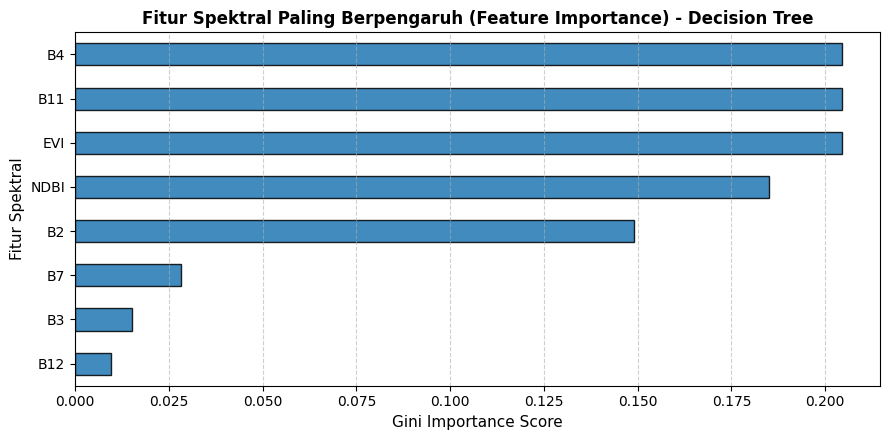

In [62]:
model_final = grid_dt.best_estimator_

# 1. Decision Rules Text
print("=== ATURAN POHON KEPUTUSAN FINAL (DECISION RULES) ===")
print(export_text(model_final, feature_names=FITUR_FINAL))

# 2. Visualisasi Feature Importance
feat_imp = pd.Series(model_final.feature_importances_, index=FITUR_FINAL).sort_values(ascending=True)

plt.figure(figsize=(9, 4.5))
feat_imp[feat_imp > 0].plot(kind="barh", color="#1f77b4", edgecolor="black", alpha=0.85)
plt.title("Fitur Spektral Paling Berpengaruh (Feature Importance) - Decision Tree", fontsize=12, fontweight='bold')
plt.xlabel("Gini Importance Score", fontsize=11)
plt.ylabel("Fitur Spektral", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---
# 7. Peta Hasil Klasifikasi (Folium + Google Satellite)

Peta interaktif berikut memvisualisasikan seluruh titik sampel hasil klasifikasi tutupan lahan di wilayah Jawa Timur dengan:
* **Basemap Google Maps Satellite (Hybrid)**: Resolusi tinggi lengkap dengan batas administrasi dan nama wilayah (`https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}`).
* **CircleMarker Tematik**: Menampilkan titik sampel dengan palet warna resmi kartografi 6 kelas.
* **Popup Interaktif**: Memuat detail ID sampel, koordinat lat/lon, status akurasi model, dan nilai indeks spektral.
* **Kotak Batas Studi (BBox Jawa Timur)**.
* **Floating Legend LULC**: Legenda kartografis mengambang di pojok layar.

In [63]:
WARNA_KELAS = {
    "Sawah": "yellow",
    "Bangunan": "red",
    "Mangrove": "darkgreen",
    "Lahan Hijau": "green",
    "Perairan Terbuka (Laut)": "blue",
    "Danau": "cyan"
}

# Area of Interest (BBox Jawa Timur)
AOI_JATIM = [111.0, -8.85, 114.65, -6.75]   # [barat, selatan, timur, utara]
pusat_peta = [(AOI_JATIM[1] + AOI_JATIM[3]) / 2, (AOI_JATIM[0] + AOI_JATIM[2]) / 2]

peta = folium.Map(location=pusat_peta, zoom_start=8, tiles=None, control_scale=True)

# 1. Base Layer Google Maps Hybrid (dengan label)
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    attr="Google Hybrid Satellite",
    name="Google Hybrid (Satelit + Label)",
    max_zoom=20,
    overlay=False,
    control=True,
).add_to(peta)

# 2. Base Layer Esri World Imagery
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics",
    name="Esri Satellite",
    max_zoom=19,
    overlay=False,
    control=True,
    show=False
).add_to(peta)

# 3. Prediksi Seluruh Sampel dengan Model Final
# Pastikan FITUR_FINAL sudah kamu definisikan sebelumnya (atau ganti dengan FITUR_SEMUA)
df["prediksi"] = model_final.predict(df[FITUR_SEMUA]) 
df["evaluasi"] = np.where(df["kelas"] == df["prediksi"], "Tepat", "Meleset")

# 4. Tambahkan Titik Sampel per Kelas ke Layer Terpisah
for nama in NAMA_KELAS:
    sub = df[df["kelas"] == nama]
    grup = folium.FeatureGroup(name=f"Sampel: {nama} ({len(sub)} Titik)", show=True)
    for _, r in sub.iterrows():
        popup_html = f"""
        <div style='font-family: Arial, sans-serif; font-size: 11px; width: 220px;'>
            <b style='color:{WARNA_KELAS[nama]}; font-size: 13px;'>{nama}</b><br>
            <b>Status Prediksi:</b> <span style='color:{"green" if r["evaluasi"]=="Tepat" else "red"}'><b>{r["evaluasi"]}</b></span><br>
            <b>Hasil Model:</b> {r["prediksi"]}<br>
            <b>Koordinat:</b> {r["lon"]:.4f} BT, {r["lat"]:.4f} LS<br>
            <hr style='margin:4px 0;'>
            <b>NDVI:</b> {r["NDVI"]:.3f} | <b>NDWI:</b> {r["NDWI"]:.3f}<br>
            <b>MNDWI:</b> {r["MNDWI"]:.3f} | <b>NDBI:</b> {r["NDBI"]:.3f}<br>
            <b>B8 (NIR):</b> {r["B8"]:.3f} | <b>B4 (Red):</b> {r["B4"]:.3f}
        </div>
        """
        folium.CircleMarker(
            [r.lat, r.lon],
            radius=5.5,
            color="white",
            weight=1.2,
            fill=True,
            fill_color=WARNA_KELAS[nama],
            fill_opacity=0.9,
            popup=folium.Popup(popup_html, max_width=250)
        ).add_to(grup)
    grup.add_to(peta)

# 5. Batas Area Studi (Jawa Timur)
grup_aoi = folium.FeatureGroup(name="Batas Area Studi (BBox Jatim)", show=True)
folium.Rectangle(
    [[AOI_JATIM[1], AOI_JATIM[0]], [AOI_JATIM[3], AOI_JATIM[2]]],
    color="yellow", weight=1.8, fill=False, dash_array="6"
).add_to(grup_aoi)
grup_aoi.add_to(peta)

# 6. Floating Legend Kartografi HTML
item = "".join(
    f'<div style="margin:3px 0;"><span style="display:inline-block;width:14px;height:14px;'
    f'background:{WARNA_KELAS[k]};border:1px solid #333;margin-right:8px;vertical-align:middle;border-radius:50%;"></span>'
    f'{k} ({len(df[df["kelas"]==k])})</div>'
    for k in NAMA_KELAS)

legenda_html = f'''
<div style="position:fixed; bottom:30px; left:30px; z-index:9999; background:white;
    padding:10px 14px; border:2px solid #555; border-radius:6px; font:12px Arial;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.3);">
<b>Legenda Tutupan Lahan (LULC)</b><br>
<small>Sentinel-2A & Decision Tree</small><hr style="margin:4px 0;">
{item}
<hr style="margin:4px 0;">
<small><b>Total: {len(df)} Titik Sampel</b></small>
</div>
'''
peta.get_root().html.add_child(folium.Element(legenda_html))
folium.LayerControl(collapsed=False).add_to(peta)
peta.fit_bounds([[AOI_JATIM[1], AOI_JATIM[0]], [AOI_JATIM[3], AOI_JATIM[2]]])

peta.save("hasil_klasifikasi_jatim.html")
print("Peta interaktif berhasil disimpan ke 'hasil_klasifikasi_jatim.html'")
peta

Peta interaktif berhasil disimpan ke 'hasil_klasifikasi_jatim.html'


---
# 8. Kesimpulan & Rekomendasi Kebijakan

1. **Akurasi Model dan Karakteristik Fitur:**
   * Kombinasi 10 band Sentinel-2A dan 8 indeks spektral (**18 fitur**) memberikan performa terbaik dalam membedakan 6 kelas tutupan lahan di Jawa Timur.
   * Saluran inframerah gelombang pendek (**B11 SWIR-1**) dan indeks air (**MNDWI**) terbukti menjadi prediktor paling menentukan dalam memisahkan badan air (laut dan danau) dari daratan dan kawasan terbangun.
   * Kanal inframerah dekat (**B8 NIR**) dan indeks **NDVI/SAVI** secara efektif membedakan vegetasi berkanopi lebat (mangrove dan hutan lahan hijau) terhadap sawah vegetatif dan kawasan terbangun.

2. **Dukungan Kebijakan Tata Ruang Berbasis Spasial di Jawa Timur:**
   * **Pemantauan LP2B (UU No. 41/2009):** Pemisahan tegas antara kelas sawah dan bangunan dapat dimanfaatkan pemda untuk sistem peringatan dini (*early warning system*) alih fungsi lahan sawah produktif.
   * **Pemenuhan 30% RTH (UU No. 26/2007):** Peta tutupan lahan ini memvalidasi proporsi tutupan hijau perkotaan di Surabaya Raya dan Malang Raya secara objektif dan berkala.
   * **Perlindungan Ekosistem Mangrove:** Deteksi mangrove di pesisir utara dan selatan Jawa Timur memberikan data geospasial presisi untuk mendukung program rehabilitasi mangrove dan perlindungan cadangan karbon biru (*blue carbon*).
   * **Penyajian Peta Publik:** Peta berbasis Folium dengan basemap satelit Google Maps memungkinkan masyarakat dan pemangku kepentingan (*stakeholders*) memverifikasi fakta lapangan secara interaktif dan transparan.
